In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
LABEL_COLS = ['antimicrobial', 'antiviral', 'antifungal', 'anticancer']

dbamp_train = pd.read_csv('dbamp_train.csv')
dbamp_val = pd.read_csv('dbamp_val.csv')
dbamp_test = pd.read_csv('dbamp_test.csv')

dramp_train = pd.read_csv('dramp_train.csv')
dramp_val = pd.read_csv('dramp_val.csv')
dramp_test = pd.read_csv('dramp_test.csv')

print('=== Dataset Sizes ===')
print(f'dbAMP  - Train: {len(dbamp_train)}, Val: {len(dbamp_val)}, Test: {len(dbamp_test)}')
print(f'DRAMP  - Train: {len(dramp_train)}, Val: {len(dramp_val)}, Test: {len(dramp_test)}')

print('\n=== Label Distribution (dbAMP train) ===')
print(dbamp_train[LABEL_COLS].sum())
print('\n=== Label Distribution (DRAMP train) ===')
print(dramp_train[LABEL_COLS].sum())

=== Dataset Sizes ===
dbAMP  - Train: 20698, Val: 2627, Test: 2577
DRAMP  - Train: 4562, Val: 457, Test: 508

=== Label Distribution (dbAMP train) ===
antimicrobial    18681
antiviral         2036
antifungal        4371
anticancer          60
dtype: int64

=== Label Distribution (DRAMP train) ===
antimicrobial    4525
antiviral         255
antifungal       1491
anticancer        126
dtype: int64


In [3]:
def create_kmers(sequence, k=3):
    """
    Convert sequence to k-mers with spaces.
    Example: 'ABCDEF' with k=3 -> 'ABC BCD CDE DEF'
    """
    return ' '.join([sequence[i:i + k] for i in range(len(sequence) - k + 1)])


def prepare_features(df, k=3):
    """Apply k-mer transformation to sequences."""
    df = df.copy()
    df['kmers'] = df['sequence'].apply(lambda x: create_kmers(x, k))
    return df


# Test k-mer creation
sample_seq = dbamp_train['sequence'].iloc[0]
print(f'\n=== K-mer Example (k=3) ===')
print(f'Original: {sample_seq[:30]}...')
print(f'K-mers:   {create_kmers(sample_seq, k=3)[:60]}...')

k = 3  # tri-peptides

dbamp_train_kmer = prepare_features(dbamp_train, k)
dbamp_val_kmer = prepare_features(dbamp_val, k)
dbamp_test_kmer = prepare_features(dbamp_test, k)

dramp_train_kmer = prepare_features(dramp_train, k)
dramp_val_kmer = prepare_features(dramp_val, k)
dramp_test_kmer = prepare_features(dramp_test, k)


=== K-mer Example (k=3) ===
Original: AAAAAAAAAAGIGKFLHSAKKFGKAFVGEI...
K-mers:   AAA AAA AAA AAA AAA AAA AAA AAA AAG AGI GIG IGK GKF KFL FLH ...


In [4]:
def train_baseline_multilabel(train_df, val_df, test_df, dataset_name,
                              label_cols=LABEL_COLS):
    """
    Train one logistic regression per label (OneVsRest) using k-mer features.
    Reports per-label and macro-averaged metrics.
    """
    print(f"\n{'=' * 60}")
    print(f'Training Baseline Multilabel Model: {dataset_name}')
    print(f"{'=' * 60}")

    X_train = train_df['kmers']
    X_val = val_df['kmers']
    X_test = test_df['kmers']

    Y_train = train_df[label_cols].values
    Y_val = val_df[label_cols].values
    Y_test = test_df[label_cols].values

    # Build pipeline: k-mer counts -> scale -> OneVsRest logistic regression
    base_lr = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    pipeline = Pipeline([
        ('vectorizer', CountVectorizer(
            analyzer='word',
            lowercase=False,
            max_features=5000
        )),
        ('scaler', StandardScaler(with_mean=False)),
        ('classifier', OneVsRestClassifier(base_lr))
    ])

    print('\nTraining...')
    pipeline.fit(X_train, Y_train)

    results = {}
    for split_name, X, Y_true in [
        ('Train', X_train, Y_train),
        ('Val', X_val, Y_val),
        ('Test', X_test, Y_test)
    ]:
        Y_pred = pipeline.predict(X)
        Y_pred_prob = pipeline.predict_proba(X)  # shape (n_samples, n_labels)

        macro_acc = accuracy_score(Y_true, Y_pred)
        macro_prec = precision_score(Y_true, Y_pred, average='macro', zero_division=0)
        macro_rec = recall_score(Y_true, Y_pred, average='macro', zero_division=0)
        macro_f1 = f1_score(Y_true, Y_pred, average='macro', zero_division=0)

        # Per-label AUC, then macro average
        per_label_auc = []
        for i, label in enumerate(label_cols):
            if len(np.unique(Y_true[:, i])) > 1:
                per_label_auc.append(roc_auc_score(Y_true[:, i], Y_pred_prob[:, i]))
            else:
                per_label_auc.append(float('nan'))
        macro_auc = np.nanmean(per_label_auc)

        results[split_name] = {
            'subset_accuracy': macro_acc,
            'macro_precision': macro_prec,
            'macro_recall': macro_rec,
            'macro_f1': macro_f1,
            'macro_auc': macro_auc,
            'per_label_auc': dict(zip(label_cols, per_label_auc))
        }

        print(f'\n{split_name} Results:')
        print(f'  Subset Accuracy : {macro_acc:.4f}')
        print(f'  Macro Precision : {macro_prec:.4f}')
        print(f'  Macro Recall    : {macro_rec:.4f}')
        print(f'  Macro F1        : {macro_f1:.4f}')
        print(f'  Macro AUC       : {macro_auc:.4f}')
        print(f'  Per-label AUC   :')
        for label, auc in zip(label_cols, per_label_auc):
            print(f'    {label:15s}: {auc:.4f}')

    print(f'\n=== Test Classification Report ===')
    Y_test_pred = pipeline.predict(X_test)
    print(classification_report(Y_test, Y_test_pred,
                                target_names=label_cols, zero_division=0))

    return pipeline, results


dbamp_model, dbamp_results = train_baseline_multilabel(
    dbamp_train_kmer, dbamp_val_kmer, dbamp_test_kmer, 'dbAMP'
)

dramp_model, dramp_results = train_baseline_multilabel(
    dramp_train_kmer, dramp_val_kmer, dramp_test_kmer, 'DRAMP'
)


Training Baseline Multilabel Model: dbAMP

Training...

Train Results:
  Subset Accuracy : 0.9392
  Macro Precision : 0.9303
  Macro Recall    : 0.9892
  Macro F1        : 0.9579
  Macro AUC       : 0.9970
  Per-label AUC   :
    antimicrobial  : 0.9999
    antiviral      : 0.9999
    antifungal     : 0.9880
    anticancer     : 1.0000

Val Results:
  Subset Accuracy : 0.6125
  Macro Precision : 0.4601
  Macro Recall    : 0.4923
  Macro F1        : 0.4750
  Macro AUC       : 0.6903
  Per-label AUC   :
    antimicrobial  : 0.8286
    antiviral      : 0.8046
    antifungal     : 0.6595
    anticancer     : 0.4685

Test Results:
  Subset Accuracy : 0.6290
  Macro Precision : 0.4355
  Macro Recall    : 0.4806
  Macro F1        : 0.4552
  Macro AUC       : 0.7400
  Per-label AUC   :
    antimicrobial  : 0.8587
    antiviral      : 0.8061
    antifungal     : 0.6566
    anticancer     : 0.6387

=== Test Classification Report ===
               precision    recall  f1-score   support

antimi

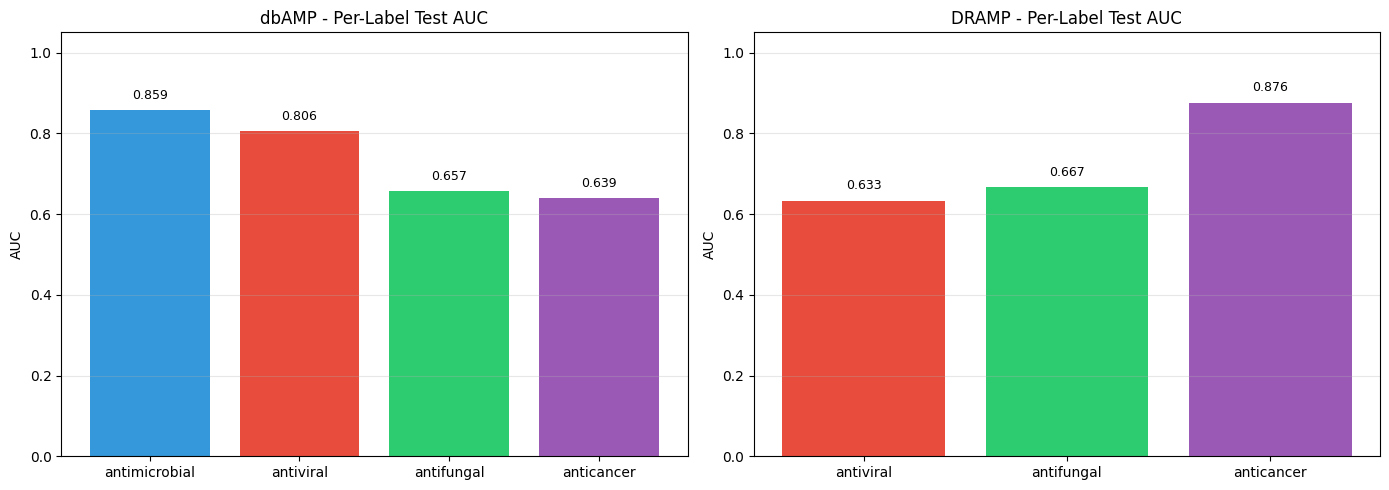

In [5]:
# ── Visualise per-label AUC on the test split ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (dataset_name, results) in zip(
        axes, [('dbAMP', dbamp_results), ('DRAMP', dramp_results)]
):
    label_aucs = results['Test']['per_label_auc']
    labels = list(label_aucs.keys())
    aucs = list(label_aucs.values())

    bars = ax.bar(labels, aucs, color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
    ax.set_ylim([0, 1.05])
    ax.set_ylabel('AUC')
    ax.set_title(f'{dataset_name} - Per-Label Test AUC')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('baseline_multilabel_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# ── Save summary CSV ──────────────────────────────────────────────────────────
rows = []
for dataset_name, results in [('dbAMP', dbamp_results), ('DRAMP', dramp_results)]:
    r = results['Test']
    row = {
        'Model': 'Baseline-LR (k=3)',
        'Dataset': dataset_name,
        'Subset_Accuracy': r['subset_accuracy'],
        'Macro_Precision': r['macro_precision'],
        'Macro_Recall': r['macro_recall'],
        'Macro_F1': r['macro_f1'],
        'Macro_AUC': r['macro_auc'],
    }
    for label, auc in r['per_label_auc'].items():
        row[f'AUC_{label}'] = auc
    rows.append(row)

results_df = pd.DataFrame(rows)
results_df.to_csv('baseline_multilabel_results.csv', index=False)
print('=== Baseline Multilabel Results Saved ===')
print(results_df.to_string(index=False))

=== Baseline Multilabel Results Saved ===
            Model Dataset  Subset_Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Macro_AUC  AUC_antimicrobial  AUC_antiviral  AUC_antifungal  AUC_anticancer
Baseline-LR (k=3)   dbAMP         0.629026         0.435508      0.480555  0.455194   0.740018           0.858655       0.806124        0.656640        0.638651
Baseline-LR (k=3)   DRAMP         0.608268         0.500600      0.612021  0.541715   0.725396                NaN       0.633333        0.666709        0.876146
